In [ ]:
import os
import cv2
import numpy as np
import scipy.io
import random
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import GridSearchCV, learning_curve, train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from datetime import datetime
import joblib
from sklearn.linear_model import SGDRegressor
from sklearn.model_selection import GridSearchCV

In [ ]:
# Data loading and preprocessing
data_dir = '/content/drive/MyDrive/FaceAnnotations2/valid2'

image_list = []
angles_list = []
filenames = []

for fname in sorted(os.listdir(data_dir)):
    if fname.endswith('.jpg'):
        img_path = os.path.join(data_dir, fname)
        mat_path = os.path.join(data_dir, fname.replace('.jpg', '.mat'))

        # Load image
        img = cv2.imread(img_path)
        if img is None:
            continue
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        image_list.append(img_rgb)

        # Load pose
        label = scipy.io.loadmat(mat_path)
        pose = label['Pose_Para'].flatten()
        pitch, yaw, roll = np.degrees(pose[0]), np.degrees(pose[1]), np.degrees(pose[2])
        angles_list.append([pitch, yaw, roll])

        # Extract file number
        file_id = fname.replace('image', '').replace('.jpg', '')
        filenames.append(file_id)

# Convert angles to NumPy array
angles_np = np.array(angles_list)

print(f"Loaded {len(image_list)} images")
print(f"Angles shape: {angles_np.shape}")
print(f"Example filename: {filenames[0]}")

Loaded 1051 images
Angles shape: (1051, 3)
Example filename: 00002


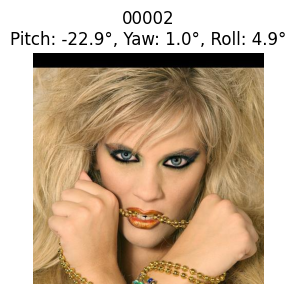

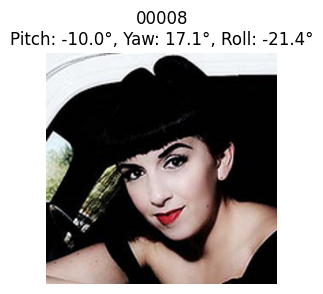

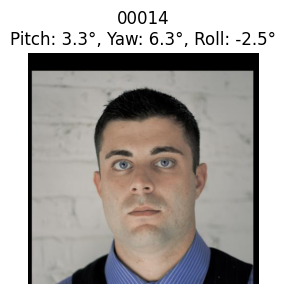

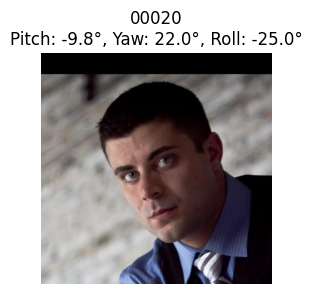

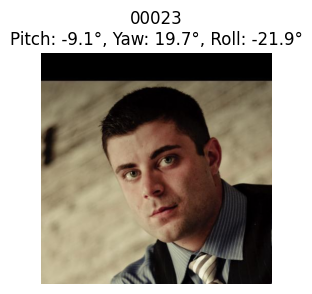

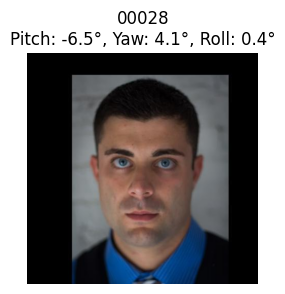

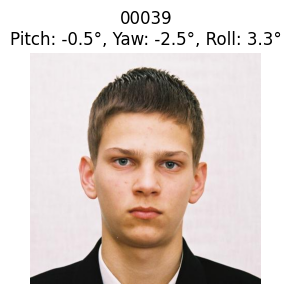

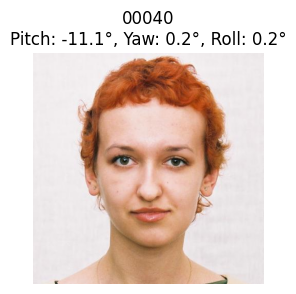

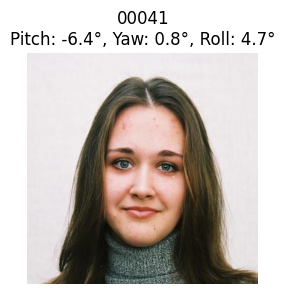

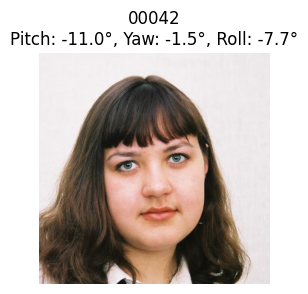

In [ ]:
# Display sample images with angles
num_samples = 10

for i in range(num_samples):
    img = image_list[i]
    angles = angles_np[i]
    fname = filenames[i]

    pitch, yaw, roll = angles

    plt.figure(figsize=(3, 3))
    plt.imshow(img)
    plt.axis('off')
    plt.title(f"{fname}\nPitch: {pitch:.1f}°, Yaw: {yaw:.1f}°, Roll: {roll:.1f}°")
    plt.show()

In [ ]:
# Install required packages
!pip install mediapipe opencv-python
import mediapipe as mp


In [ ]:
# Initialize MediaPipe Face Mesh and process images
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
face_mesh = mp_face_mesh.FaceMesh(min_detection_confidence=0.8)

num_samples = 100
random_indices = random.sample(range(len(image_list)), num_samples)

for i in random_indices:
    img = image_list[i].copy()
    angles = angles_np[i]
    fname = filenames[i]

    # Convert the image to RGB (needed by MediaPipe)
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Process the image for face landmarks
    results = face_mesh.process(image_rgb)

    feature_vector = []

    # Check if any landmarks were detected
    if results.multi_face_landmarks:
        # Process the first detected face
        face_landmarks = results.multi_face_landmarks[0]  # Only use the first face

        left_eye_pts = []
        right_eye_pts = []

        # Populate the left eye points list using a traditional for loop
        for i in [33, 133, 160, 144, 153, 158]:
            left_eye_pts.append((face_landmarks.landmark[i].x,
                                face_landmarks.landmark[i].y,
                                face_landmarks.landmark[i].z))

        # Populate the right eye points list using a traditional for loop
        for i in [362, 263, 387, 373, 380, 385]:
            right_eye_pts.append((face_landmarks.landmark[i].x,
                                  face_landmarks.landmark[i].y,
                                  face_landmarks.landmark[i].z))

        # Convert the lists into numpy arrays
        left_eye_center = np.mean(left_eye_pts, axis=0)
        right_eye_center = np.mean(right_eye_pts, axis=0)

        # Extract additional facial landmarks
        forehead = face_landmarks.landmark[10]  # Forehead center
        nose_tip = face_landmarks.landmark[1]   # Nose tip
        mouth_left = face_landmarks.landmark[61]  # Mouth left corner
        mouth_right = face_landmarks.landmark[291] # Mouth right corner
        chin = face_landmarks.landmark[152]      # Chin tip

        # Add new landmarks for left temporal and right temporal
        left_temporal = face_landmarks.landmark[137]
        right_temporal = face_landmarks.landmark[366]

        # Creating the feature list
        features = [
            ('Left Eye Center', left_eye_center[0], left_eye_center[1], left_eye_center[2]),
            ('Right Eye Center', right_eye_center[0], right_eye_center[1], right_eye_center[2]),
            ('Forehead Center', forehead.x, forehead.y, forehead.z),
            ('Nose Tip', nose_tip.x, nose_tip.y, nose_tip.z),
            ('Mouth Left Corner', mouth_left.x, mouth_left.y, mouth_left.z),
            ('Mouth Right Corner', mouth_right.x, mouth_right.y, mouth_right.z),
            ('Chin Tip', chin.x, chin.y, chin.z),
            ('Left Temporal', left_temporal.x, left_temporal.y, left_temporal.z),
            ('Right Temporal', right_temporal.x, right_temporal.y, right_temporal.z)
        ]

        # Add these features to the feature vector
        feature_vector.extend(features)

        for name, x, y, z in features:
            px, py = int(x * img.shape[1]), int(y * img.shape[0])  # Convert to pixel coordinates
            cv2.circle(img, (px, py), 3, (0, 255, 0), -1)

    # Display the image with landmarks
    image_rgb_with_landmarks = img
    plt.figure(figsize=(5, 5))
    plt.imshow(image_rgb_with_landmarks)
    plt.axis('off')
    plt.title(f"{fname}\nPitch: {angles[0]:.1f}°, Yaw: {angles[1]:.1f}°, Roll: {angles[2]:.1f}°")
    plt.show()

    # Print the feature vector (landmark names with coordinates)
    print(f"Selected Facial Landmarks for {fname}:")
    for name, x, y, z in feature_vector:
        print(f"{name}: x={x:.3f}, y={y:.3f}, z={z:.3f}")
    print("\n---\n")

In [ ]:
# Initialize MediaPipe Face Mesh with same parameters as second implementation
mp_face_mesh = mp.solutions.face_mesh
mp_drawing = mp.solutions.drawing_utils
face_mesh = mp_face_mesh.FaceMesh(static_image_mode=True,
                                 max_num_faces=1,
                                 min_detection_confidence=0.8)

# Initialize output CSV file
output_csv = 'facial_landmarks.csv'
data = []
column_names = ['image_name']

# Define landmarks structure (same as original first implementation)
column_names.extend(['left_eye_center_x', 'left_eye_center_y', 'left_eye_center_z'])
column_names.extend(['right_eye_center_x', 'right_eye_center_y', 'right_eye_center_z'])
column_names.extend(['forehead_center_x', 'forehead_center_y', 'forehead_center_z'])
column_names.extend(['nose_tip_x', 'nose_tip_y', 'nose_tip_z'])
column_names.extend(['mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_left_corner_z'])
column_names.extend(['mouth_right_corner_x', 'mouth_right_corner_y', 'mouth_right_corner_z'])
column_names.extend(['chin_tip_x', 'chin_tip_y', 'chin_tip_z'])
column_names.extend(['left_temporal_x', 'left_temporal_y', 'left_temporal_z'])
column_names.extend(['right_temporal_x', 'right_temporal_y', 'right_temporal_z'])
column_names.extend(['roll', 'pitch', 'yaw'])

# Directory containing images (same as second implementation)
data_dir = '/content/drive/MyDrive/FaceAnnotations2/valid2'
for fname in sorted(os.listdir(data_dir)):
    if not fname.endswith('.jpg'):
        continue

    image_path = os.path.join(data_dir, fname)
    mat_path = os.path.join(data_dir, fname.replace('.jpg', '.mat'))

    if not os.path.exists(mat_path):
        continue

    img = cv2.imread(image_path)
    if img is None:
        continue

    # Load pose angles from .mat file (same as second implementation)
    label = scipy.io.loadmat(mat_path)
    pose = label['Pose_Para'].flatten()
    pitch, yaw, roll = np.degrees(pose[0]), np.degrees(pose[1]), np.degrees(pose[2])

    # Convert the image to RGB (needed by MediaPipe)
    image_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Process the image for face landmarks
    results = face_mesh.process(image_rgb)

    # Initialize row for CSV
    row = [fname]

    # Check if any landmarks were detected
    if results.multi_face_landmarks:
        # Process the first detected face
        face_landmarks = results.multi_face_landmarks[0]  # Only use the first face

        # Extract left and right eye centers (same as original first implementation)
        left_eye_pts = [(face_landmarks.landmark[i].x, face_landmarks.landmark[i].y, face_landmarks.landmark[i].z) for i in [33, 133, 160, 144, 153, 158]]
        right_eye_pts = [(face_landmarks.landmark[i].x, face_landmarks.landmark[i].y, face_landmarks.landmark[i].z) for i in [362, 263, 387, 373, 380, 385]]

        left_eye_center = np.mean(left_eye_pts, axis=0)
        right_eye_center = np.mean(right_eye_pts, axis=0)

        # Extract additional facial landmarks (same as original first implementation)
        forehead = face_landmarks.landmark[10]  # Forehead center
        nose_tip = face_landmarks.landmark[1]   # Nose tip
        mouth_left = face_landmarks.landmark[61]  # Mouth left corner
        mouth_right = face_landmarks.landmark[291] # Mouth right corner
        chin = face_landmarks.landmark[152]      # Chin tip
        left_temporal = face_landmarks.landmark[137]
        right_temporal = face_landmarks.landmark[366]

        # Add the features to the row for CSV
        row.extend([left_eye_center[0], left_eye_center[1], left_eye_center[2]])
        row.extend([right_eye_center[0], right_eye_center[1], right_eye_center[2]])
        row.extend([forehead.x, forehead.y, forehead.z])
        row.extend([nose_tip.x, nose_tip.y, nose_tip.z])
        row.extend([mouth_left.x, mouth_left.y, mouth_left.z])
        row.extend([mouth_right.x, mouth_right.y, mouth_right.z])
        row.extend([chin.x, chin.y, chin.z])
        row.extend([left_temporal.x, left_temporal.y, left_temporal.z])
        row.extend([right_temporal.x, right_temporal.y, right_temporal.z])

        # Add roll, pitch, yaw to the row (now loaded from .mat file)
        row.extend([roll, pitch, yaw])  # Note: order matches second implementation

        # Append the row to the data list
        data.append(row)

# Save the extracted features to a CSV file
df = pd.DataFrame(data, columns=column_names)
df.to_csv(output_csv, index=False)

print(f"Features saved to: {output_csv}")
print(f"Dataset shape: {df.shape}")

Features saved to: facial_landmarks.csv
Dataset shape: (1029, 31)


In [ ]:
# Load and inspect the saved CSV
df = pd.read_csv('facial_landmarks.csv')
print(f"Dataset shape: {df.shape}")
print(f"Column names: {list(df.columns)}\n")
print("Random samples:")
print(df.sample(5).to_string(index=False))

Dataset shape: (1029, 31)
Column names: ['image_name', 'left_eye_center_x', 'left_eye_center_y', 'left_eye_center_z', 'right_eye_center_x', 'right_eye_center_y', 'right_eye_center_z', 'forehead_center_x', 'forehead_center_y', 'forehead_center_z', 'nose_tip_x', 'nose_tip_y', 'nose_tip_z', 'mouth_left_corner_x', 'mouth_left_corner_y', 'mouth_left_corner_z', 'mouth_right_corner_x', 'mouth_right_corner_y', 'mouth_right_corner_z', 'chin_tip_x', 'chin_tip_y', 'chin_tip_z', 'left_temporal_x', 'left_temporal_y', 'left_temporal_z', 'right_temporal_x', 'right_temporal_y', 'right_temporal_z', 'roll', 'pitch', 'yaw']

Random samples:
    image_name  left_eye_center_x  left_eye_center_y  left_eye_center_z  right_eye_center_x  right_eye_center_y  right_eye_center_z  forehead_center_x  forehead_center_y  forehead_center_z  nose_tip_x  nose_tip_y  nose_tip_z  mouth_left_corner_x  mouth_left_corner_y  mouth_left_corner_z  mouth_right_corner_x  mouth_right_corner_y  mouth_right_corner_z  chin_tip_x  chi

In [ ]:
# Yaw feature engineering
landmark_df = pd.read_csv('facial_landmarks.csv')
yaw_df = pd.DataFrame()


yaw_df['image_name'] = landmark_df['image_name']

yaw_df['nose_minus_mouth_left_x'] = landmark_df['nose_tip_x'] - landmark_df['mouth_left_corner_x']
yaw_df['nose_minus_mouth_right_x'] = landmark_df['nose_tip_x'] - landmark_df['mouth_right_corner_x']
yaw_df['nose_minus_right_eye_x'] = landmark_df['nose_tip_x'] - landmark_df['right_eye_center_x']
yaw_df['nose_minus_left_eye_x'] = landmark_df['nose_tip_x'] - landmark_df['left_eye_center_x']
yaw_df['nose_minus_left_temporal_x'] = landmark_df['nose_tip_x'] - landmark_df['left_temporal_x']
yaw_df['nose_minus_right_temporal_x'] = landmark_df['nose_tip_x'] - landmark_df['right_temporal_x']
yaw_df['yaw'] = landmark_df['yaw']

print("Yaw-related feature dataset shape:", yaw_df.shape)
print("Feature names:", list(yaw_df.columns))
print("\nSample rows:")
print(yaw_df.sample(5).to_string(index=False))

Yaw-related feature dataset shape: (1029, 8)
Feature names: ['image_name', 'nose_minus_mouth_left_x', 'nose_minus_mouth_right_x', 'nose_minus_right_eye_x', 'nose_minus_left_eye_x', 'nose_minus_left_temporal_x', 'nose_minus_right_temporal_x', 'yaw']

Sample rows:
    image_name  nose_minus_mouth_left_x  nose_minus_mouth_right_x  nose_minus_right_eye_x  nose_minus_left_eye_x  nose_minus_left_temporal_x  nose_minus_right_temporal_x        yaw
image01488.jpg                 0.136400                  0.053976                0.016798               0.103066                    0.283848                     0.065081 -65.697662
image04007.jpg                 0.038325                 -0.108171               -0.152115               0.058608                    0.136243                    -0.323712  15.196328
image01200.jpg                 0.011889                 -0.156070               -0.129625               0.035302                    0.069670                    -0.285357  24.517847
image02246.jp

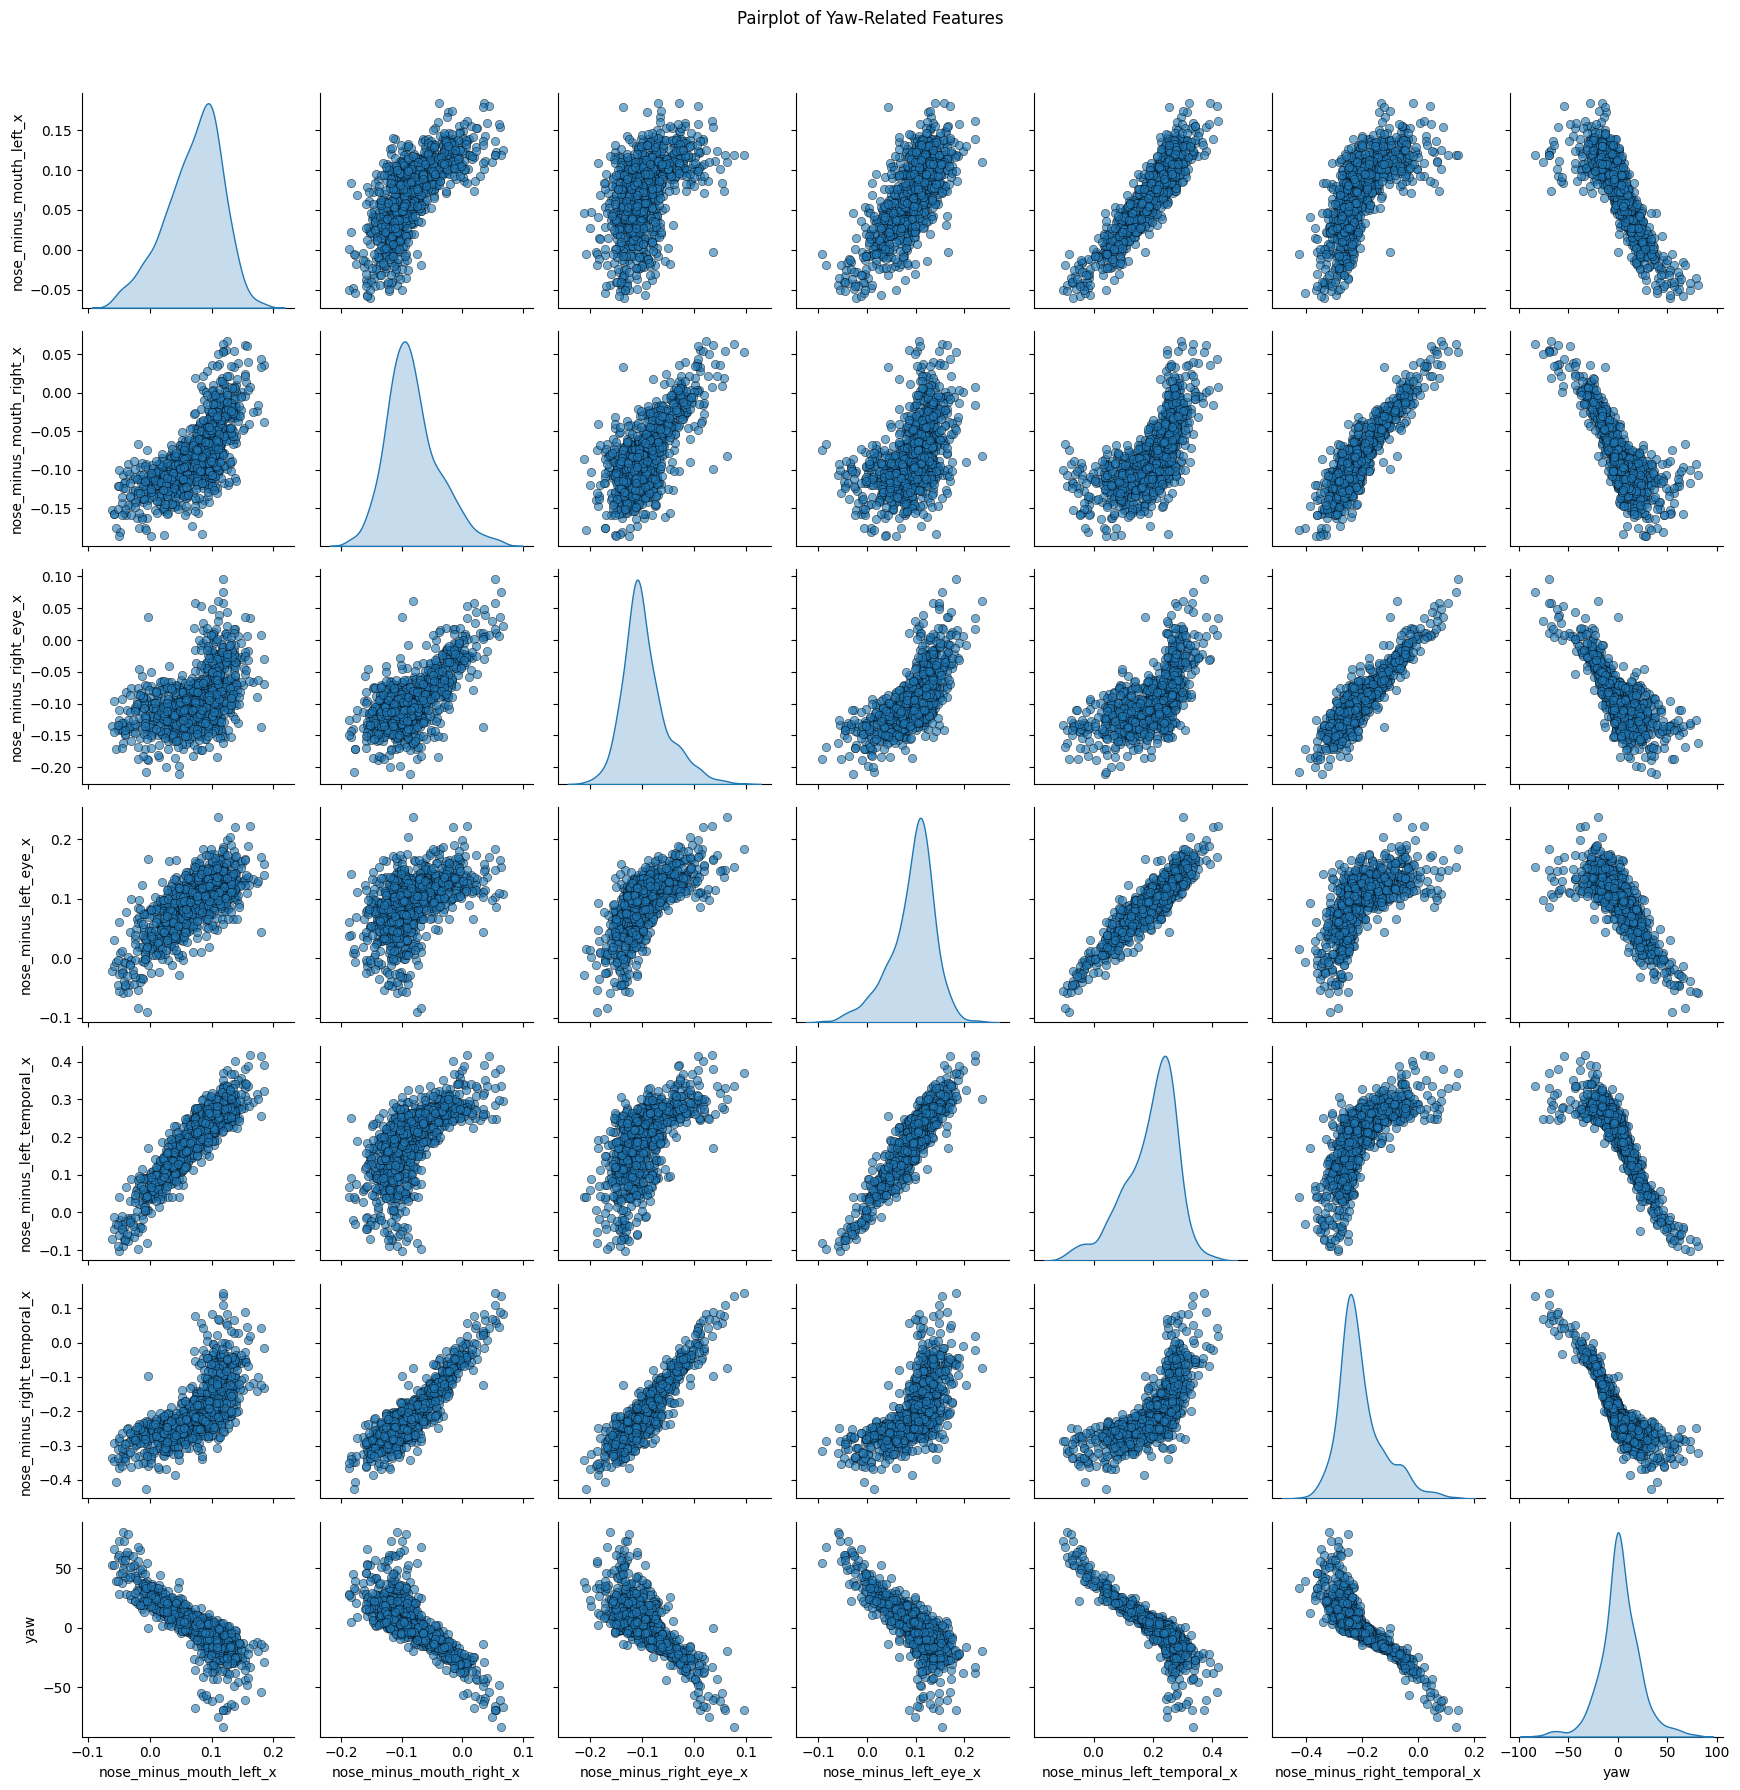

In [ ]:
# Yaw visualization
yaw_features = yaw_df.drop(columns=['image_name'])
sns.pairplot(yaw_features, diag_kind='kde', plot_kws={'alpha': 0.6, 'edgecolor': 'k'})
plt.suptitle('Pairplot of Yaw-Related Features', y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
# Yaw model training - SVR
X_yaw = yaw_df.drop(columns=['image_name', 'yaw'])
y_yaw = yaw_df['yaw']

X_train_yaw, X_test_yaw, y_train_yaw, y_test_yaw = train_test_split(X_yaw, y_yaw, test_size=0.2, random_state=42)

scaler_yaw = StandardScaler()
X_train_yaw_scaled = scaler_yaw.fit_transform(X_train_yaw)
X_test_yaw_scaled = scaler_yaw.transform(X_test_yaw)


Starting hyperparameter tuning for Yaw at 16:48:14
Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best parameters for Yaw at 16:50:50:
{'C': 1, 'coef0': 1, 'degree': 3, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'poly'}
Final Model Performance for Yaw:
Mean Absolute Error: 2.4143
Mean Squared Error: 11.0266
Root Mean Squared Error: 3.3206
R² Score: 0.9708


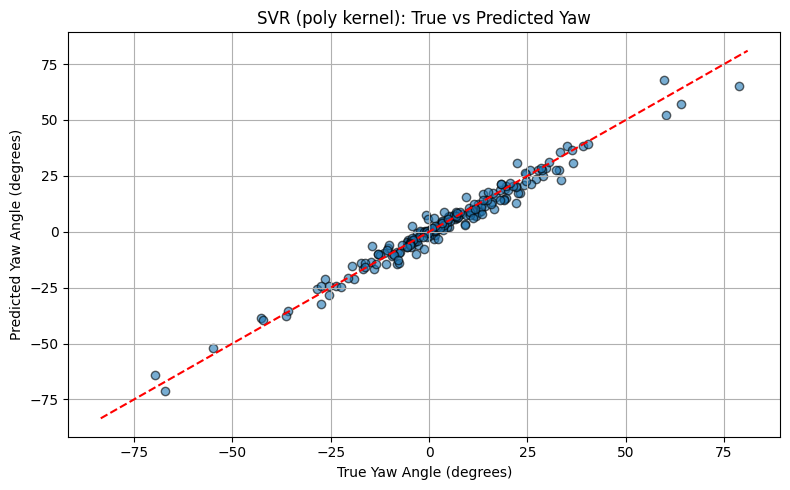

Top 5 parameter combinations for Yaw:


,param_kernel,param_C,param_epsilon,param_gamma,param_degree,param_coef0,mean_test_score,rank_test_score
139,poly,1.0,0.5,auto,3.0,1.0,-14.996526,1
138,poly,1.0,0.5,scale,3.0,1.0,-14.999748,2
104,poly,0.5,0.1,scale,3.0,1.0,-15.023479,3
105,poly,0.5,0.1,auto,3.0,1.0,-15.024566,4
106,poly,0.5,0.5,scale,3.0,1.0,-15.067883,5


In [ ]:

param_grid_yaw = [
    {
        'kernel': ['linear'],
        'C': [0.5, 1, 10, 50],
        'epsilon': [0.05, 0.1, 0.5]
    },
    {
        'kernel': ['rbf'],
        'C': [0.5, 1, 10, 50],
        'gamma': ['scale', 'auto'] + list(np.logspace(-2, 1, 4)),
        'epsilon': [0.05, 0.1, 0.5]
    },
    {
        'kernel': ['poly'],
        'C': [0.5, 1, 10],
        'degree': [2, 3, 4, 5],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.1, 0.5],
        'coef0': [0, 1]
    }
]

grid_search_yaw = GridSearchCV(
    SVR(),
    param_grid_yaw,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

print(f"Starting hyperparameter tuning for Yaw at {datetime.now().strftime('%H:%M:%S')}")

grid_search_yaw.fit(X_train_yaw_scaled, y_train_yaw)

best_svr_yaw = grid_search_yaw.best_estimator_
print(f"Best parameters for Yaw at {datetime.now().strftime('%H:%M:%S')}:")
print(grid_search_yaw.best_params_)

y_pred_yaw = best_svr_yaw.predict(X_test_yaw_scaled)
mae_yaw = mean_absolute_error(y_test_yaw, y_pred_yaw)
mse_yaw = mean_squared_error(y_test_yaw, y_pred_yaw)
rmse_yaw = mse_yaw ** 0.5
r2_yaw = r2_score(y_test_yaw, y_pred_yaw)

print("Final Model Performance for Yaw:")
print(f"Mean Absolute Error: {mae_yaw:.4f}")
print(f"Mean Squared Error: {mse_yaw:.4f}")
print(f"Root Mean Squared Error: {rmse_yaw:.4f}")
print(f"R² Score: {r2_yaw:.4f}")

if best_svr_yaw.kernel == 'linear':
    print("Linear Model Weights and Bias:")
    print("Weights:", best_svr_yaw.coef_)
    print("Bias:", best_svr_yaw.intercept_)

plt.figure(figsize=(8, 5))
plt.scatter(y_test_yaw, y_pred_yaw, alpha=0.6, edgecolor='k')
plt.plot([y_yaw.min(), y_yaw.max()], [y_yaw.min(), y_yaw.max()], 'r--')
plt.xlabel('True Yaw Angle (degrees)')
plt.ylabel('Predicted Yaw Angle (degrees)')
plt.title(f'SVR ({best_svr_yaw.kernel} kernel): True vs Predicted Yaw')
plt.grid(True)
plt.tight_layout()
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    best_svr_yaw,
    X_train_yaw_scaled,
    y_train_yaw,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1
)

results_df_yaw = pd.DataFrame(grid_search_yaw.cv_results_)
print("Top 5 parameter combinations for Yaw:")
top_results_yaw = results_df_yaw.sort_values('rank_test_score').head(5)[[
    'param_kernel', 'param_C', 'param_epsilon', 'param_gamma',
    'param_degree', 'param_coef0', 'mean_test_score', 'rank_test_score'
]]
display(top_results_yaw)

In [ ]:
# Save the model
joblib.dump(best_svr_yaw, 'best_svr_yaw_model.joblib')

# Optionally, save the scaler too (needed during inference!)
joblib.dump(scaler_yaw, 'scaler_yaw.joblib')

['scaler_yaw.joblib']

In [ ]:
# Yaw model training - Random Forest
param_grid_yaw = {
    'n_estimators': [50, 100, 200],
    'max_depth': [ 10, 20],
}

print("Tuning Random Forest for Yaw...")
rf_yaw = RandomForestRegressor(random_state=42)
grid_yaw = GridSearchCV(rf_yaw, param_grid_yaw, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)

grid_yaw.fit(X_train_yaw, y_train_yaw)

best_yaw = grid_yaw.best_estimator_
y_pred_yaw = best_yaw.predict(X_test_yaw)

mae_yaw = mean_absolute_error(y_test_yaw, y_pred_yaw)
mse_yaw = mean_squared_error(y_test_yaw, y_pred_yaw)
rmse_yaw = mse_yaw ** 0.5
r2_yaw = r2_score(y_test_yaw, y_pred_yaw)

print(f"Best Parameters for Yaw: {grid_yaw.best_params_}")
print(f"MAE: {mae_yaw:.4f}")
print(f"MSE: {mse_yaw:.4f}")
print(f"RMSE: {rmse_yaw:.4f}")
print(f"R² Score: {r2_yaw:.4f}")

Tuning Random Forest for Yaw...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters for Yaw: {'max_depth': 20, 'n_estimators': 100}
MAE: 2.6939
MSE: 15.7001
RMSE: 3.9623
R² Score: 0.9585


In [ ]:
sgd_yaw = SGDRegressor(random_state=42)

# Define hyperparameters to tune
param_grid_sgd = {

    'eta0': [0.001, 0.01, 0.1],
}

# Grid search
grid_sgd = GridSearchCV(sgd_yaw, param_grid_sgd, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_sgd.fit(X_train_yaw, y_train_yaw)

# Best model
best_sgd = grid_sgd.best_estimator_
y_pred_yaw = best_sgd.predict(X_test_yaw)

# Metrics
mae_yaw = mean_absolute_error(y_test_yaw, y_pred_yaw)
mse_yaw = mean_squared_error(y_test_yaw, y_pred_yaw)
rmse_yaw = mse_yaw ** 0.5
r2_yaw = r2_score(y_test_yaw, y_pred_yaw)

print(f"Best Parameters for SGD: {grid_sgd.best_params_}")
print(f"MAE: {mae_yaw:.4f}")
print(f"MSE: {mse_yaw:.4f}")
print(f"RMSE: {rmse_yaw:.4f}")
print(f"R² Score: {r2_yaw:.4f}")


Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters for SGD: {'eta0': 0.01}
MAE: 3.9553
MSE: 42.0094
RMSE: 6.4815
R² Score: 0.8888


In [ ]:
# Roll feature engineering
roll_df = pd.DataFrame()
roll_df['image_name'] = landmark_df['image_name']

roll_df['chin_minus_forehead_x'] = landmark_df['chin_tip_x'] - landmark_df['forehead_center_x']
roll_df['chin_minus_right_temporal_x'] = landmark_df['chin_tip_x'] - landmark_df['right_temporal_x']
roll_df['chin_minus_left_temporal_x'] = landmark_df['chin_tip_x'] - landmark_df['left_temporal_x']
roll_df['roll'] = landmark_df['roll']

print("Roll-related feature dataset shape:", roll_df.shape)
print("Feature names:", list(roll_df.columns))
print("\nSample rows:")
print(roll_df.sample(5).to_string(index=False))

Roll-related feature dataset shape: (1029, 5)
Feature names: ['image_name', 'chin_minus_forehead_x', 'chin_minus_right_temporal_x', 'chin_minus_left_temporal_x', 'roll']

Sample rows:
    image_name  chin_minus_forehead_x  chin_minus_right_temporal_x  chin_minus_left_temporal_x       roll
image01421.jpg               0.144464                    -0.124799                    0.267309 -17.244963
image02213.jpg               0.261022                    -0.183828                    0.222357 -23.249300
image01062.jpg              -0.082167                    -0.131449                    0.231928   8.929958
image00516.jpg              -0.040509                    -0.112539                    0.212172   5.616868
image00567.jpg               0.018911                    -0.223188                    0.135078  -2.294466


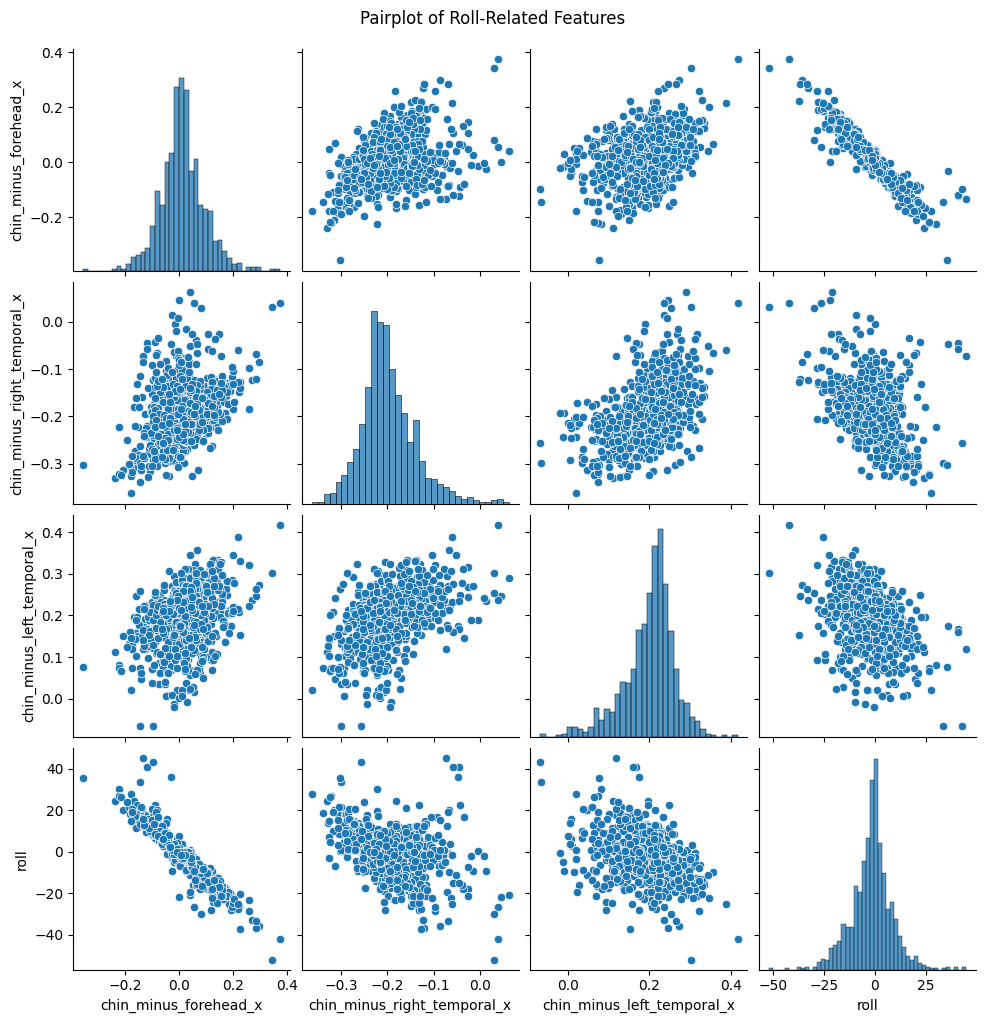

In [ ]:
# Roll visualization
roll_plot_df = roll_df.drop(columns=['image_name'])
sns.pairplot(roll_plot_df)
plt.suptitle("Pairplot of Roll-Related Features", y=1.02)
plt.show()

In [ ]:
X_roll = roll_df.drop(columns=['image_name', 'roll'])
y_roll = roll_df['roll']

X_train_roll, X_test_roll, y_train_roll, y_test_roll = train_test_split(X_roll, y_roll, test_size=0.2, random_state=42)

scaler_roll = StandardScaler()
X_train_roll_scaled = scaler_roll.fit_transform(X_train_roll)
X_test_roll_scaled = scaler_roll.transform(X_test_roll)

Starting hyperparameter tuning for Roll at 16:52:42
Fitting 5 folds for each of 132 candidates, totalling 660 fits
Best parameters found at 16:53:26:
{'C': 10, 'coef0': 1, 'degree': 3, 'epsilon': 0.5, 'gamma': 'auto', 'kernel': 'poly'}
Final Model Performance:
Mean Absolute Error: 1.5283
Mean Squared Error: 6.9729
Root Mean Squared Error: 2.6406
R² Score: 0.9425


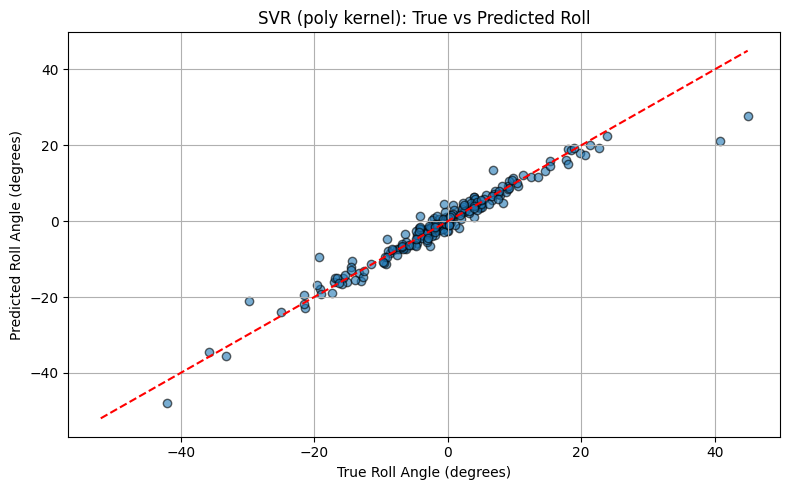

Top 5 parameter combinations:


,param_kernel,param_C,param_epsilon,param_gamma,param_degree,param_coef0,mean_test_score,rank_test_score
131,poly,10.0,0.5,auto,3.0,1.0,-6.837934,1
130,poly,10.0,0.5,scale,3.0,1.0,-6.838958,2
98,poly,0.5,0.5,scale,3.0,1.0,-6.864825,3
99,poly,0.5,0.5,auto,3.0,1.0,-6.865117,4
115,poly,1.0,0.5,auto,3.0,1.0,-6.874752,5


In [ ]:
# Roll model training - SVR


param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.5, 1, 10, 50],
        'epsilon': [0.05, 0.1, 0.5]
    },
    {
        'kernel': ['rbf'],
        'C': [0.5, 1, 10, 50],
        'gamma': ['scale', 'auto'] + list(np.logspace(-2, 1, 4)),
        'epsilon': [0.05, 0.1, 0.5]
    },
    {
        'kernel': ['poly'],
        'C': [0.5, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.1, 0.5],
        'coef0': [0, 1]
    }
]

grid_search = GridSearchCV(
    SVR(),
    param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

print(f"Starting hyperparameter tuning for Roll at {datetime.now().strftime('%H:%M:%S')}")

grid_search.fit(X_train_roll_scaled, y_train_roll)

best_svr = grid_search.best_estimator_
print(f"Best parameters found at {datetime.now().strftime('%H:%M:%S')}:")
print(grid_search.best_params_)

y_pred_roll = best_svr.predict(X_test_roll_scaled)
mae_roll = mean_absolute_error(y_test_roll, y_pred_roll)
mse_roll = mean_squared_error(y_test_roll, y_pred_roll)
rmse_roll = mse_roll ** 0.5
r2_roll = r2_score(y_test_roll, y_pred_roll)

print("Final Model Performance:")
print(f"Mean Absolute Error: {mae_roll:.4f}")
print(f"Mean Squared Error: {mse_roll:.4f}")
print(f"Root Mean Squared Error: {rmse_roll:.4f}")
print(f"R² Score: {r2_roll:.4f}")

if best_svr.kernel == 'linear':
    w = best_svr.coef_
    b = best_svr.intercept_
    print("Final Linear SVR Formula:")
    print(f"Roll Prediction = ({w.flatten()} @ x) + {b[0]}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test_roll, y_pred_roll, alpha=0.6, edgecolor='k')
plt.plot([y_roll.min(), y_roll.max()], [y_roll.min(), y_roll.max()], 'r--')
plt.xlabel('True Roll Angle (degrees)')
plt.ylabel('Predicted Roll Angle (degrees)')
plt.title(f'SVR ({best_svr.kernel} kernel): True vs Predicted Roll')
plt.grid(True)
plt.tight_layout()
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    best_svr,
    X_train_roll_scaled,
    y_train_roll,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1
)
"""
plt.figure()
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Loss')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validation Loss')
plt.xlabel('Training Set Size')
plt.ylabel('Loss (MSE)')
plt.title(f'Learning Curve: SVR ({best_svr.kernel} kernel)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""
results_df = pd.DataFrame(grid_search.cv_results_)
print("Top 5 parameter combinations:")
top_results = results_df.sort_values('rank_test_score').head(5)[[
    'param_kernel', 'param_C', 'param_epsilon', 'param_gamma',
    'param_degree', 'param_coef0', 'mean_test_score', 'rank_test_score'
]]
display(top_results)

In [ ]:

# Save the Roll SVR model
joblib.dump(best_svr, 'best_svr_roll_model.joblib')

# Save the associated scaler
joblib.dump(scaler_roll, 'scaler_roll.joblib')


['scaler_roll.joblib']

In [ ]:
# Roll model training - Random Forest
param_grid_roll = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20],

}

print("Tuning Random Forest for Roll...")
rf_roll = RandomForestRegressor(random_state=42)
grid_roll = GridSearchCV(rf_roll, param_grid_roll, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_roll.fit(X_train_roll, y_train_roll)

best_roll = grid_roll.best_estimator_
y_pred_roll = best_roll.predict(X_test_roll)

mae_roll = mean_absolute_error(y_test_roll, y_pred_roll)
mse_roll = mean_squared_error(y_test_roll, y_pred_roll)
rmse_roll = mse_roll ** 0.5
r2_roll = r2_score(y_test_roll, y_pred_roll)

print(f"Best Parameters for Roll: {grid_roll.best_params_}")
print(f"MAE: {mae_roll:.4f}")
print(f"MSE: {mse_roll:.4f}")
print(f"RMSE: {rmse_roll:.4f}")
print(f"R² Score: {r2_roll:.4f}")

Tuning Random Forest for Roll...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters for Roll: {'max_depth': 10, 'n_estimators': 100}
MAE: 1.8516
MSE: 8.6737
RMSE: 2.9451
R² Score: 0.9284


In [ ]:

# Define the hyperparameter grid for SGDRegressor
param_grid_roll = {
    'eta0': [0.001, 0.01, 0.1],

}

# Set up GridSearchCV to find the best parameters
print("Tuning SGDRegressor for Roll...")
sgd_roll = SGDRegressor(random_state=42)

grid_roll = GridSearchCV(sgd_roll, param_grid_roll, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_roll.fit(X_train_roll_scaled, y_train_roll)

# Get the best model
best_roll = grid_roll.best_estimator_

# Predict using the best model
y_pred_roll = best_roll.predict(X_test_roll_scaled)

# Calculate metrics
mae_roll = mean_absolute_error(y_test_roll, y_pred_roll)
mse_roll = mean_squared_error(y_test_roll, y_pred_roll)
rmse_roll = mse_roll ** 0.5
r2_roll = r2_score(y_test_roll, y_pred_roll)

# Output the results
print(f"Best Parameters for Roll: {grid_roll.best_params_}")
print(f"MAE: {mae_roll:.4f}")
print(f"MSE: {mse_roll:.4f}")
print(f"RMSE: {rmse_roll:.4f}")
print(f"R² Score: {r2_roll:.4f}")


Tuning SGDRegressor for Roll...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters for Roll: {'eta0': 0.01}
MAE: 2.0613
MSE: 15.4594
RMSE: 3.9318
R² Score: 0.8725


In [ ]:
# Pitch feature engineering
pitch_df = pd.DataFrame()
pitch_df['image_name'] = landmark_df['image_name']

pitch_df['nose_minus_chin_y'] = landmark_df['nose_tip_y'] - landmark_df['chin_tip_y']
pitch_df['chin_minus_forehead_z'] = landmark_df['chin_tip_z'] - landmark_df['forehead_center_z']
pitch_df['nose_minus_left_temporal_y'] = landmark_df['nose_tip_y'] - landmark_df['left_temporal_y']
pitch_df['nose_minus_right_temporal_y'] = landmark_df['nose_tip_y'] - landmark_df['right_temporal_y']
pitch_df['pitch'] = landmark_df['pitch']

print("Pitch-related feature dataset shape:", pitch_df.shape)
print("Feature names:", list(pitch_df.columns))
print("\nSample rows:")
print(pitch_df.sample(5).to_string(index=False))

Pitch-related feature dataset shape: (1029, 6)
Feature names: ['image_name', 'nose_minus_chin_y', 'chin_minus_forehead_z', 'nose_minus_left_temporal_y', 'nose_minus_right_temporal_y', 'pitch']

Sample rows:
    image_name  nose_minus_chin_y  chin_minus_forehead_z  nose_minus_left_temporal_y  nose_minus_right_temporal_y      pitch
image00892.jpg          -0.180210               0.273219                    0.104998                     0.083499 -16.577810
image03263.jpg          -0.180879               0.133778                    0.083112                     0.103119 -25.563574
image02869.jpg          -0.214505              -0.003959                   -0.043615                     0.083316   1.541609
image01932.jpg          -0.199696               0.234914                    0.071126                     0.109123 -19.857641
image03813.jpg          -0.206888               0.087302                    0.057759                    -0.013772  -2.802148


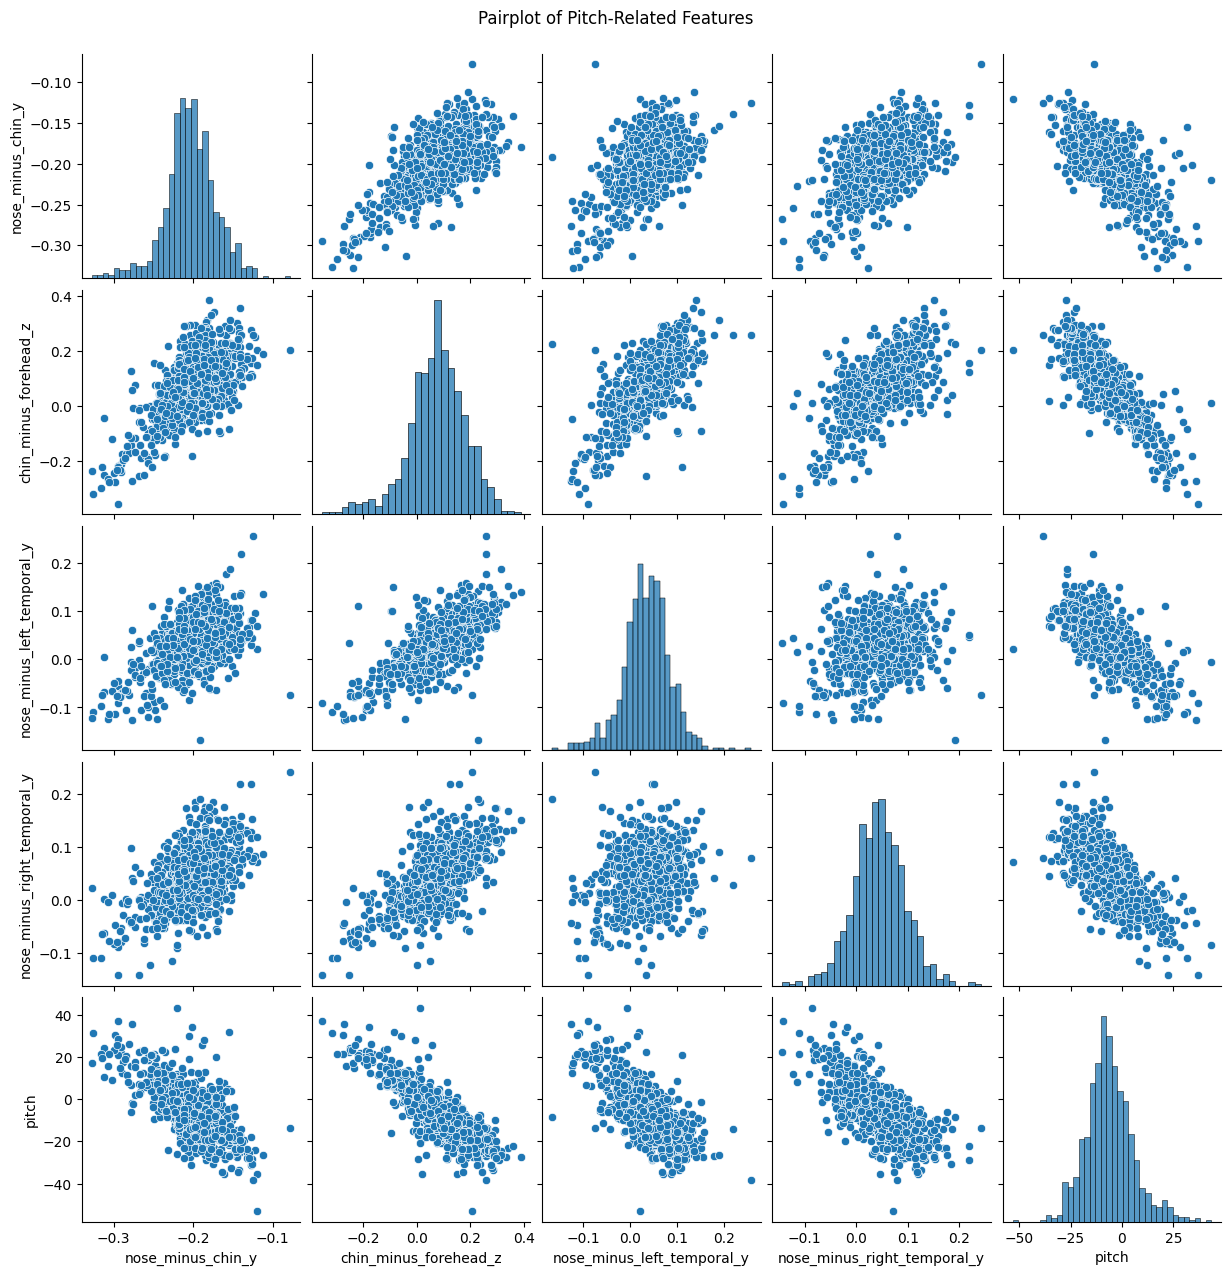

In [ ]:
# Pitch visualization
pitch_plot_df = pitch_df.drop(columns=['image_name'])
sns.pairplot(pitch_plot_df)
plt.suptitle("Pairplot of Pitch-Related Features", y=1.02)
plt.show()

In [ ]:
X_pitch = pitch_df.drop(columns=['image_name', 'pitch'])
y_pitch = pitch_df['pitch']

X_train_pitch, X_test_pitch, y_train_pitch, y_test_pitch = train_test_split(X_pitch, y_pitch, test_size=0.2, random_state=42)

scaler_pitch = StandardScaler()
X_train_pitch_scaled = scaler_pitch.fit_transform(X_train_pitch)
X_test_pitch_scaled = scaler_pitch.transform(X_test_pitch)

Starting hyperparameter tuning for Pitch at 16:54:56
Fitting 5 folds for each of 132 candidates, totalling 660 fits
Best parameters found at 16:55:34:
{'C': 50, 'epsilon': 0.05, 'gamma': 0.01, 'kernel': 'rbf'}
Final Model Performance for Pitch:
Mean Absolute Error: 3.3220
Mean Squared Error: 19.1047
Root Mean Squared Error: 4.3709
R² Score: 0.8448


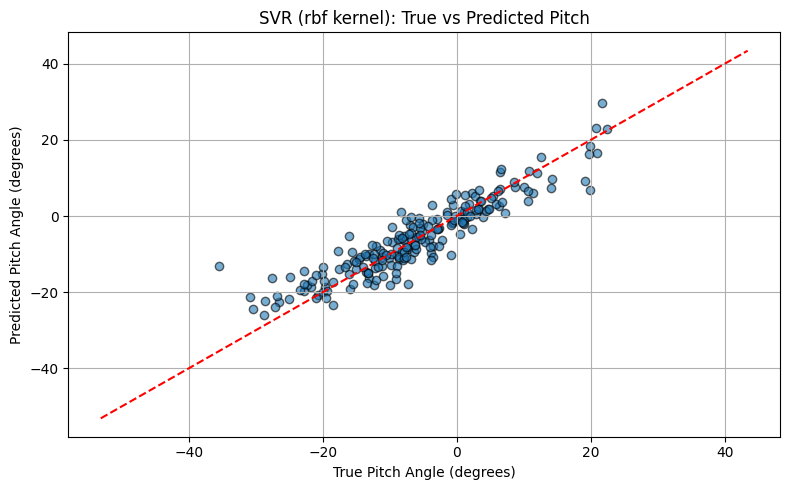

Top 5 parameter combinations for Pitch:


,param_kernel,param_C,param_epsilon,param_gamma,param_degree,param_coef0,mean_test_score,rank_test_score
68,rbf,50.0,0.05,0.01,NaN,NaN,-25.022296,1
80,rbf,50.0,0.50,0.01,NaN,NaN,-25.029696,2
74,rbf,50.0,0.10,0.01,NaN,NaN,-25.034223,3
110,poly,1.0,0.50,scale,2.0,1.0,-25.048285,4
111,poly,1.0,0.50,auto,2.0,1.0,-25.054764,5


In [ ]:


param_grid_pitch = [
    {
        'kernel': ['linear'],
        'C': [0.5, 1, 10, 50],
        'epsilon': [0.05, 0.1, 0.5]
    },
    {
        'kernel': ['rbf'],
        'C': [0.5, 1, 10, 50],
        'gamma': ['scale', 'auto'] + list(np.logspace(-2, 1, 4)),
        'epsilon': [0.05, 0.1, 0.5]
    },
    {
        'kernel': ['poly'],
        'C': [0.5, 1, 10],
        'degree': [2, 3],
        'gamma': ['scale', 'auto'],
        'epsilon': [0.1, 0.5],
        'coef0': [0, 1]
    }
]

grid_search_pitch = GridSearchCV(
    SVR(),
    param_grid_pitch,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=2
)

print(f"Starting hyperparameter tuning for Pitch at {datetime.now().strftime('%H:%M:%S')}")

grid_search_pitch.fit(X_train_pitch_scaled, y_train_pitch)

best_svr_pitch = grid_search_pitch.best_estimator_
print(f"Best parameters found at {datetime.now().strftime('%H:%M:%S')}:")
print(grid_search_pitch.best_params_)

y_pred_pitch = best_svr_pitch.predict(X_test_pitch_scaled)
mae_pitch = mean_absolute_error(y_test_pitch, y_pred_pitch)
mse_pitch = mean_squared_error(y_test_pitch, y_pred_pitch)
rmse_pitch = mse_pitch ** 0.5
r2_pitch = r2_score(y_test_pitch, y_pred_pitch)

print("Final Model Performance for Pitch:")
print(f"Mean Absolute Error: {mae_pitch:.4f}")
print(f"Mean Squared Error: {mse_pitch:.4f}")
print(f"Root Mean Squared Error: {rmse_pitch:.4f}")
print(f"R² Score: {r2_pitch:.4f}")

if best_svr_pitch.kernel == 'linear':
    w = best_svr_pitch.coef_
    b = best_svr_pitch.intercept_
    print("Final Linear SVR Formula:")
    print(f"Pitch Prediction = ({w.flatten()} @ x) + {b[0]}")

plt.figure(figsize=(8, 5))
plt.scatter(y_test_pitch, y_pred_pitch, alpha=0.6, edgecolor='k')
plt.plot([y_pitch.min(), y_pitch.max()], [y_pitch.min(), y_pitch.max()], 'r--')
plt.xlabel('True Pitch Angle (degrees)')
plt.ylabel('Predicted Pitch Angle (degrees)')
plt.title(f'SVR ({best_svr_pitch.kernel} kernel): True vs Predicted Pitch')
plt.grid(True)
plt.tight_layout()
plt.show()

train_sizes, train_scores, test_scores = learning_curve(
    best_svr_pitch,
    X_train_pitch_scaled,
    y_train_pitch,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=1
)
"""
plt.figure()
plt.plot(train_sizes, -train_scores.mean(axis=1), label='Training Loss')
plt.plot(train_sizes, -test_scores.mean(axis=1), label='Validation Loss')
plt.xlabel('Training Set Size')
plt.ylabel('Loss (MSE)')
plt.title(f'Learning Curve: SVR ({best_svr_pitch.kernel} kernel) for Pitch')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
"""
results_df_pitch = pd.DataFrame(grid_search_pitch.cv_results_)
print("Top 5 parameter combinations for Pitch:")
top_results_pitch = results_df_pitch.sort_values('rank_test_score').head(5)[[
    'param_kernel', 'param_C', 'param_epsilon', 'param_gamma',
    'param_degree', 'param_coef0', 'mean_test_score', 'rank_test_score'
]]
display(top_results_pitch)

In [ ]:

# Save the Roll SVR model
joblib.dump(best_svr_pitch, 'best_svr_pitch_model.joblib')

# Save the associated scaler
joblib.dump(scaler_pitch, 'scaler_pitch.joblib')


['scaler_pitch.joblib']

In [ ]:
# Pitch model training - Random Forest
param_grid_pitch = {
    'n_estimators': [50, 100, 200],
    'max_depth': [10, 20],

}

print("Tuning Random Forest for Pitch...")
rf_pitch = RandomForestRegressor(random_state=42)
grid_pitch = GridSearchCV(rf_pitch, param_grid_pitch, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_pitch.fit(X_train_pitch, y_train_pitch)

best_pitch = grid_pitch.best_estimator_
y_pred_pitch = best_pitch.predict(X_test_pitch)

mae_pitch = mean_absolute_error(y_test_pitch, y_pred_pitch)
mse_pitch = mean_squared_error(y_test_pitch, y_pred_pitch)
rmse_pitch = mse_pitch ** 0.5
r2_pitch = r2_score(y_test_pitch, y_pred_pitch)

print(f"Best Parameters for Pitch: {grid_pitch.best_params_}")
print(f"MAE: {mae_pitch:.4f}")
print(f"MSE: {mse_pitch:.4f}")
print(f"RMSE: {rmse_pitch:.4f}")
print(f"R² Score: {r2_pitch:.4f}")

Tuning Random Forest for Pitch...
Fitting 5 folds for each of 6 candidates, totalling 30 fits
Best Parameters for Pitch: {'max_depth': 10, 'n_estimators': 200}
MAE: 3.6291
MSE: 26.2421
RMSE: 5.1227
R² Score: 0.7869


In [ ]:

# Define the hyperparameter grid for SGDRegressor
param_grid_pitch = {
    'eta0': [0.001, 0.01, 0.1],

}

# Set up GridSearchCV to find the best parameters
print("Tuning SGDRegressor for Pitch...")
sgd_pitch = SGDRegressor(random_state=42)

grid_pitch = GridSearchCV(sgd_pitch, param_grid_pitch, cv=5, scoring='neg_mean_squared_error', n_jobs=-1, verbose=1)
grid_pitch.fit(X_train_pitch_scaled, y_train_pitch)

# Get the best model
best_pitch = grid_pitch.best_estimator_

# Predict using the best model
y_pred_pitch = best_pitch.predict(X_test_pitch_scaled)

# Calculate metrics
mae_pitch = mean_absolute_error(y_test_pitch, y_pred_pitch)
mse_pitch = mean_squared_error(y_test_pitch, y_pred_pitch)
rmse_pitch = mse_pitch ** 0.5
r2_pitch = r2_score(y_test_pitch, y_pred_pitch)

# Output the results
print(f"Best Parameters for Pitch: {grid_pitch.best_params_}")
print(f"MAE: {mae_pitch:.4f}")
print(f"RMSE: {rmse_pitch:.4f}")
print(f"R² Score: {r2_pitch:.4f}")


Tuning SGDRegressor for Pitch...
Fitting 5 folds for each of 3 candidates, totalling 15 fits
Best Parameters for Pitch: {'eta0': 0.01}
MAE: 3.3881
RMSE: 4.6844
R² Score: 0.8218
